**CityFlo Bus Service — Metro Cities: Exploratory Data Analysis**

**Dataset**: cityflo_bus_service_metro_cities.csv (3,258 rows × 36 columns) <br> **Workflow followed:** Exploratory Data Analysis — A Standard 23-Step Checklist for Any Dataset

This notebook walks through all 23 steps of the checklist, in order, across four phases:
| Phase | Steps | Goal |
|-------|:-----:|------|
| **Phase 1 — Inspect** | 1–8 | Understand the shape, structure, and quality of the raw data |
| **Phase 2 — Clean & Prepare** | 9–17 | Organize columns, clean values, export a final clean dataset |
| **Phase 3 — Analyze** | 18–21 | Explore relationships and statistically test them |
| **Phase 4 — Report** | 22–23 | Define KPIs and charts for the final dashboard |

Each step below has its own markdown explanation followed by the code that performs it.

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

RAW_PATH = "/content/drive/MyDrive/Cityflow_Bus_Services/cityflo_bus_service_metro_cities.csv"
df = pd.read_csv(RAW_PATH)
df.head()

,trip_id,booking_id,customer_id,customer_name,gender,age,city,route_id,route_name,origin_stop,destination_stop,bus_number,bus_type,driver_id,driver_name,trip_date,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,distance_km,fare_inr,discount_inr,payment_mode,booking_channel,seat_number,trip_status,cancellation_reason,rating,occupancy_pct,weather,is_peak_hour,subscription_type,device_type,gps_enabled,complaint_raised
0,TRP000768,BK47984879,CUST01278,Shalini Verma,Female,21.0,Mumbai,RTMU005,Lower Parel - Mulund,Lower Parel,Mulund,MH23CF4441,AC Sleeper,DRV0080,Aarav Bhat,2024-09-21,20:25,20:25,20:58,20:58,10.9,153,0.0,UPI,Corporate Portal,D8,Completed,NaN,5.0,84.6,Haze,0,Corporate Plan,iOS,true,No
1,TRP002439,BK14257322,CUST01290,Kalpana Chopra,Male,24.0,Hyderabad,RTHY038,HITEC City - Kondapur,HITEC City,Kondapur,TS27CF8651,AC Seater,DRV0068,Sanjay Joshi,2024-08-08,14:50,15:12,15:29,15:51,14.1,127,0.0,Debit Card,Kiosk,D7,Delayed-Completed,NaN,NaN,28.3,Heavy Rain,False,Weekly Pass,Android,True,0
2,TRP000793,BK67236768,CUST01285,Sai Naidu,Female,18.0,Pune,RTPU012,Aundh - Magarpatta,Aundh,Magarpatta,MH24CF3646,AC Seater,DRV0001,Lakshmi Patel,2024-03-19,08:15,08:15,09:42,09:42,27.6,234,19.0,Cash,Corporate Portal,D11,Completed,NaN,3.0,15.4,Cloudy,1,Single Ride,Android,Yes,No
3,TRP002802,BK59659578,CUST00625,Priya Patel,Female,23.0,Mumbai,RTMU010,Ghatkopar - Lower Parel,Ghatkopar,Lower Parel,MH13CF5853,AC Sleeper,DRV0036,Siddharth Kumar,2024-12-29,17:45,17:45,18:57,NaN,28.6,310,0.0,Debit Card,Corporate Portal,D11,No-show,Customer Request,NaN,68.1,Clear,No,Corporate Plan,Web,1,Yes
4,TRP001653,BK19231279,CUST00276,Shalini Kulkarni,F,20.0,Bangalore,RTBA024,Hebbal - Electronic City,Hebbal,Electronic City,KA22CF6238,AC Seater,DRV0045,Sunita Gupta,2024-05-15,13:00,13:40,13:35,14:15,17.8,202,0.0,UPI,Corporate Portal,A1,Delayed-Completed,NaN,NaN,23.7,Haze,No,Corporate Plan,iOS,True,0


**Phase 1 — Inspect the Raw Data (Steps 1–8)** <br>
Understand the shape, structure, and quality of the raw data.

**Step 1 — Total Number of Rows** <br>
Check the row count to understand the dataset's size (df.shape[0]).

In [2]:
n_rows = df.shape[0]
print(f"Total rows: {n_rows}")

Total rows: 3258


**Step 2 — Total Number of Columns** <br>
Check the column count (df.shape[1]).

In [3]:
n_cols = df.shape[1]
print(f"Total columns: {n_cols}")

Total columns: 36


**Step 3 — Understanding of Each Column** <br>
Go through every column and note what it represents, its expected values, and how it relates to the problem.

| Column | Represents | Expected Values |
|--------|------------|-----------------|
| **trip_id** | Unique trip identifier | TRPxxxxxx |
| **booking_id** | Unique booking transaction ID | BKxxxxxxxx |
| **customer_id** | Unique customer identifier | CUSTxxxxx |
| **customer_name** | Passenger name | Free text |
| **gender** | Passenger gender | Male / Female / Other (messy variants) |
| **age** | Passenger age | 18–65 (a few data-entry errors) |
| **city** | Metro city of operation | Mumbai, Pune, Bangalore, Hyderabad, Chennai, Delhi NCR |
| **route_id / route_name** | Route identifier / "Origin - Destination" | e.g., RTMU005, "Lower Parel - Mulund" |
| **origin_stop / destination_stop** | Pickup / Drop locality | Locality names per city |
| **bus_number** | Vehicle registration | State-coded registration number |
| **bus_type** | Bus category | AC Seater, AC Sleeper, Non-AC Seater, Premium AC |
| **driver_id / driver_name** | Assigned driver | DRVxxxx / Driver name |
| **trip_date** | Date of trip | Mixed formats (needs standardization) |
| **scheduled_departure / actual_departure / scheduled_arrival / actual_arrival** | Trip timings | HH:MM, blank if cancelled |
| **distance_km** | Route distance | Approximately 8–42 km |
| **fare_inr** | Ticket fare | Mixed formats (₹, INR, commas) |
| **discount_inr** | Discount applied | 0 or positive INR |
| **payment_mode** | Payment method | UPI, Card, Wallet, Cash, Net Banking |
| **booking_channel** | Booking source | Mobile App, Website, Kiosk, Corporate Portal |
| **seat_number** | Assigned seat | e.g., A5 |
| **trip_status** | Trip outcome | Completed, Delayed-Completed, Cancelled, No-show |
| **cancellation_reason** | Reason for cancellation/no-show | Populated only when relevant |
| **rating** | Customer rating | 1–5, missing for non-completed trips |
| **occupancy_pct** | Bus occupancy percentage | 0–100 (a few values >100 due to data-entry errors) |
| **weather** | Weather during trip | Clear, Rain, Cloudy, Fog, Heavy Rain, Haze |
| **is_peak_hour** | Whether trip occurred during peak hours | Yes/No/1/0/True/False (messy boolean) |
| **subscription_type** | Customer subscription plan | Single Ride, Weekly Pass, Monthly Pass, Corporate Plan |
| **device_type** | Booking device | Android, iOS, Web |
| **gps_enabled** | GPS tracking status | Messy boolean values |
| **complaint_raised** | Whether a complaint was raised | Messy boolean values |

In [4]:
info_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "sample_value": df.iloc[0]
})
info_df

,dtype,n_unique,sample_value
trip_id,object,3200,TRP000768
booking_id,object,3200,BK47984879
customer_id,object,1251,CUST01278
customer_name,object,866,Shalini Verma
gender,object,11,Female
age,float64,40,21.0
city,object,12,Mumbai
route_id,object,60,RTMU005
route_name,object,60,Lower Parel - Mulund
origin_stop,object,40,Lower Parel


**Step 4 — Trim Extra Spaces** <br>
Strip leading/trailing whitespace from string columns and column headers — hidden spaces silently break groupby, filtering, and joins. We first detect which columns are affected before fixing them (the actual fix happens formally in Step 16, but we flag it here as required by Step 4).

In [5]:
# Column headers - check for stray whitespace
print("Header whitespace issues:", [c for c in df.columns if c != c.strip()])

# Detect string columns with leading/trailing whitespace
obj_cols = df.select_dtypes(include="object").columns
whitespace_flagged = {
    col: int((df[col].astype(str).str.strip() != df[col].astype(str)).sum())
    for col in obj_cols
}
{k: v for k, v in whitespace_flagged.items() if v > 0}

Header whitespace issues: []


{'customer_name': 122, 'gender': 783, 'city': 104}

**Step 5 — Remove Duplicate Elements** <br>
Identify and drop duplicate rows (df.duplicated(), df.drop_duplicates()).

In [6]:
n_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")
df.loc[df.duplicated(keep=False)].sort_values("trip_id").head(6)

Fully duplicated rows: 58


,trip_id,booking_id,customer_id,customer_name,gender,age,city,route_id,route_name,origin_stop,destination_stop,bus_number,bus_type,driver_id,driver_name,trip_date,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,distance_km,fare_inr,discount_inr,payment_mode,booking_channel,seat_number,trip_status,cancellation_reason,rating,occupancy_pct,weather,is_peak_hour,subscription_type,device_type,gps_enabled,complaint_raised
2082,TRP000045,BK31856387,CUST00757,Ananya Menon,M,32.0,Pune,RTPU014,Shivajinagar - Aundh,Shivajinagar,Aundh,MH48CF6442,Premium AC,DRV0010,Sai Iyer,2024-12-12,20:20,NaN,20:41,NaN,9.3,0,0.0,NaN,Corporate Portal,D1,Cancelled,Driver Unavailable,NaN,NaN,Haze,Yes,Monthly Pass,Android,True,0
2771,TRP000045,BK31856387,CUST00757,Ananya Menon,M,32.0,Pune,RTPU014,Shivajinagar - Aundh,Shivajinagar,Aundh,MH48CF6442,Premium AC,DRV0010,Sai Iyer,2024-12-12,20:20,NaN,20:41,NaN,9.3,0,0.0,NaN,Corporate Portal,D1,Cancelled,Driver Unavailable,NaN,NaN,Haze,Yes,Monthly Pass,Android,True,0
2765,TRP000085,BK64561490,CUST00511,Sunita Malhotra,Female,25.0,Mumbai,RTMU004,Thane West - BKC,Thane West,BKC,MH16CF7658,Premium AC,DRV0048,Divya Rao,2024-12-13,20:10,20:10,21:53,21:53,41.7,752,0.0,Debit Card,Corporate Portal,A7,Completed,NaN,5.0,95.0,Haze,False,Weekly Pass,iOS,true,0
1668,TRP000085,BK64561490,CUST00511,Sunita Malhotra,Female,25.0,Mumbai,RTMU004,Thane West - BKC,Thane West,BKC,MH16CF7658,Premium AC,DRV0048,Divya Rao,2024-12-13,20:10,20:10,21:53,21:53,41.7,752,0.0,Debit Card,Corporate Portal,A7,Completed,NaN,5.0,95.0,Haze,False,Weekly Pass,iOS,true,0
2093,TRP000234,BK53828083,CUST00340,Karan Pillai,Male,19.0,Pune,RTPU013,Hadapsar - Kothrud,Hadapsar,Kothrud,MH17CF2891,AC Seater,DRV0065,Vikram Bansal,06/01/2024,09:10,09:37,09:29,09:56,9.1,97,0.0,Cash,Mobile App,B15,Delayed-Completed,NaN,5.0,68.6,Fog,0,Corporate Plan,Web,1,No
2799,TRP000234,BK53828083,CUST00340,Karan Pillai,Male,19.0,Pune,RTPU013,Hadapsar - Kothrud,Hadapsar,Kothrud,MH17CF2891,AC Seater,DRV0065,Vikram Bansal,06/01/2024,09:10,09:37,09:29,09:56,9.1,97,0.0,Cash,Mobile App,B15,Delayed-Completed,NaN,5.0,68.6,Fog,0,Corporate Plan,Web,1,No


**Step 6 — Check Memory Size**  <br>
Check memory usage (df.memory_usage(deep=True)) — flags if dtypes need downcasting for efficiency.

In [7]:
mem = df.memory_usage(deep=True)
print(mem)
print(f"\nTotal memory: {mem.sum() / 1024**2:.2f} MB")

Index                     132
trip_id                188964
booking_id             192222
customer_id            188964
customer_name          198257
gender                 173487
age                     26064
city                   183804
route_id               182448
route_name             227747
origin_stop            188905
destination_stop       188710
bus_number             192222
bus_type               193935
driver_id              182448
driver_name            196754
trip_date              193857
scheduled_departure    175932
actual_departure       167572
scheduled_arrival      175932
actual_arrival         160092
distance_km             26064
fare_inr               180112
discount_inr            26064
payment_mode           174607
booking_channel        190617
seat_number            167407
trip_status            191404
cancellation_reason    127439
rating                  26064
occupancy_pct           26064
weather                176941
is_peak_hour           168351
subscripti

**Step 7 — Check Data Type of Columns** <br>
Verify each column's dtype matches what it should be (e.g., dates not stored as text, numbers not stored as objects).

In [8]:
df.dtypes

,0
trip_id,object
booking_id,object
customer_id,object
customer_name,object
gender,object
age,float64
city,object
route_id,object
route_name,object
origin_stop,object


In [9]:
# Columns that SHOULD be numeric/datetime but are currently loaded as object (text)
should_be_numeric = ["age", "distance_km", "fare_inr", "discount_inr", "rating", "occupancy_pct"]
should_be_datetime = ["trip_date"]
should_be_boolean = ["is_peak_hour", "gps_enabled", "complaint_raised"]

print("Currently wrong dtype (numeric expected):")
print(df[should_be_numeric].dtypes)
print("\nCurrently wrong dtype (datetime expected):")
print(df[should_be_datetime].dtypes)
print("\nCurrently wrong dtype (boolean expected):")
print(df[should_be_boolean].dtypes)

Currently wrong dtype (numeric expected):
age              float64
distance_km      float64
fare_inr          object
discount_inr     float64
rating           float64
occupancy_pct    float64
dtype: object

Currently wrong dtype (datetime expected):
trip_date    object
dtype: object

Currently wrong dtype (boolean expected):
is_peak_hour        object
gps_enabled         object
complaint_raised    object
dtype: object


** Step 8 — Check Total Number of Null Values** <br>
Count missing values per column (df.isnull().sum()) to plan the cleaning strategy.

In [10]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df) * 100).round(2)
pd.DataFrame({"nulls": null_counts, "pct_missing": null_pct}).loc[null_counts > 0]

,nulls,pct_missing
cancellation_reason,2538,77.90
rating,1075,33.00
actual_arrival,720,22.10
actual_departure,380,11.66
payment_mode,380,11.66
occupancy_pct,380,11.66
discount_inr,184,5.65
age,64,1.96
driver_name,32,0.98


**Phase 2 — Clean & Prepare (Steps 9–17)** <br>
Organize columns, clean values, and export a final clean dataset.

**Step 9 — Split Columns: Numerical vs Categorical** <br>
Separate columns into numerical and categorical groups — they need different analysis and cleaning approaches. (Split is based on intended type, since several numeric columns are still stored as text at this point.)

In [11]:
numerical_cols = ["age", "distance_km", "fare_inr", "discount_inr", "rating", "occupancy_pct"]
categorical_cols = ["gender", "city", "bus_type", "payment_mode", "booking_channel",
                     "trip_status", "cancellation_reason", "weather", "subscription_type",
                     "device_type", "is_peak_hour", "gps_enabled", "complaint_raised"]
datetime_cols = ["trip_date", "scheduled_departure", "actual_departure",
                  "scheduled_arrival", "actual_arrival"]
id_cols = ["trip_id", "booking_id", "customer_id", "route_id", "driver_id", "bus_number"]

print("Numerical:", numerical_cols)
print("\nCategorical:", categorical_cols)
print("\nDate/Time:", datetime_cols)
print("\nID columns:", id_cols)

Numerical: ['age', 'distance_km', 'fare_inr', 'discount_inr', 'rating', 'occupancy_pct']

Categorical: ['gender', 'city', 'bus_type', 'payment_mode', 'booking_channel', 'trip_status', 'cancellation_reason', 'weather', 'subscription_type', 'device_type', 'is_peak_hour', 'gps_enabled', 'complaint_raised']

Date/Time: ['trip_date', 'scheduled_departure', 'actual_departure', 'scheduled_arrival', 'actual_arrival']

ID columns: ['trip_id', 'booking_id', 'customer_id', 'route_id', 'driver_id', 'bus_number']


**Step 10 — describe() of Numerical Columns** <br>
Run df.describe() to see count, mean, std, min, quartiles, and max. Note: fare_inr still has mixed text formatting at this stage, so we coerce it to numeric first just for this preview (the permanent fix happens in Step 16).

In [12]:
preview = df.copy()
preview["fare_inr_preview"] = (
    preview["fare_inr"].astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("INR", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
preview["fare_inr_preview"] = pd.to_numeric(preview["fare_inr_preview"], errors="coerce")

preview[["age", "distance_km", "fare_inr_preview", "discount_inr", "rating", "occupancy_pct"]].describe()

,age,distance_km,fare_inr_preview,discount_inr,rating,occupancy_pct
count,3194.000000,3258.000000,3258.000000,3074.000000,2183.000000,2878.000000
mean,29.477145,24.696071,287.565991,14.365973,3.798443,58.313343
std,8.251467,10.311346,223.933495,31.070065,1.163396,25.073318
min,-5.000000,8.300000,0.000000,0.000000,1.000000,15.100000
25%,23.000000,16.000000,132.250000,0.000000,3.000000,36.700000
50%,29.000000,25.700000,286.000000,0.000000,4.000000,58.500000
75%,35.000000,33.100000,402.000000,8.000000,5.000000,79.500000
max,130.000000,41.800000,3288.000000,203.000000,5.000000,138.800000


**Step 11 — Write a Summary of the Dataset**
**Summary:** This is a synthetic, trip-level dataset simulating a premium AC bus service (CityFlo-style) operating across six Indian metro cities — Mumbai, Pune, Bangalore, Hyderabad, Chennai, and Delhi NCR. Each of the 3,258 rows represents one passenger trip booked across 2024, capturing customer demographics, route/bus details, scheduled vs. actual timings, fare and payment information, occupancy, ratings, and trip outcomes (completed, delayed, cancelled, or no-show). <br>

**Source:** Synthetically generated for EDA-workflow practice (not real operator data). <br>

**Size:** 3,258 rows × 36 columns (~882 KB), including 58 intentional exact-duplicate rows. <br>

**General quality:**   Deliberately "raw" — it contains inconsistent category labels (e.g. Male/M/male), mixed boolean representations (Yes/No/1/0/True/False), mixed date formats, currency-symbol/comma inconsistencies in fare_inr, stray whitespace, missing values in several columns (mostly context-dependent, e.g. no rating for cancelled trips), and a handful of outliers / data-entry errors (negative ages, >100% occupancy, extreme fares).

In [13]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Cities covered: {sorted(df['city'].str.strip().unique())}")
print(f"Date range (raw, unparsed sample): {df['trip_date'].min()} .. {df['trip_date'].max()}")
print(f"Trip status breakdown:\n{df['trip_status'].value_counts()}")

Rows: 3,258  |  Columns: 36
Cities covered: ['Bangalore', 'Chennai', 'Delhi NCR', 'Hyderabad', 'Mumbai', 'Pune']
Date range (raw, unparsed sample): 01-Feb-2024 .. September 27, 2024
Trip status breakdown:
trip_status
Completed            2148
Delayed-Completed     390
Cancelled             380
No-show               340
Name: count, dtype: int64


**Step 12 — Write the Problem Statement** <br>
Problem Statement: What factors drive trip delays, cancellations, and low customer satisfaction in CityFlo's metro-city bus operations, and how do demand, revenue, and occupancy vary across cities, routes, bus types, and time (peak vs. non-peak, day of week, month)?

This drives every scoping decision from here on — which columns are required, which derived metrics matter, and which relationships we test statistically.

**Step 13 — Mention the Columns That Are Required**
Columns needed to answer the problem statement above:

**Identifiers (for joins/grouping):** trip_id, customer_id, route_id <br>
**Where:** city, route_name, origin_stop, destination_stop, bus_type <br>
**When**: trip_date, scheduled_departure, actual_departure, scheduled_arrival, actual_arrival, is_peak_hour <br>
**Trip outcome:** trip_status, cancellation_reason, rating, occupancy_pct, complaint_raised <br>
**Money:** distance_km, fare_inr, discount_inr, payment_mode <br>
**Context:** weather, subscription_type, booking_channel, gps_enabled
Demographics: gender, age

**Step 14 — Drop the Columns That Are Not Required**
Not needed to answer the problem statement — either purely transactional IDs with no analytic value, or personally identifiable information not required once customer_id is retained for grouping:

**booking_id —** transactional ID, no analytic value once trip_id exists <br>
**customer_name —** PII, not needed for aggregate analysis (customer_id retained) <br>
**driver_id, driver_name —** outside the stated problem's scope (route/city/ops level, not driver-level) <br>
**bus_number —** redundant once bus_type + city are retained <br>
**seat_number —** no analytic value <br>
**device_type —** outside the stated problem's scope

In [14]:
cols_to_drop = ["booking_id", "customer_name", "driver_id", "driver_name",
                 "bus_number", "seat_number", "device_type"]
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns. Remaining: {df.shape[1]}")
df.columns.tolist()

Dropped 7 columns. Remaining: 29


['trip_id',
 'customer_id',
 'gender',
 'age',
 'city',
 'route_id',
 'route_name',
 'origin_stop',
 'destination_stop',
 'bus_type',
 'trip_date',
 'scheduled_departure',
 'actual_departure',
 'scheduled_arrival',
 'actual_arrival',
 'distance_km',
 'fare_inr',
 'discount_inr',
 'payment_mode',
 'booking_channel',
 'trip_status',
 'cancellation_reason',
 'rating',
 'occupancy_pct',
 'weather',
 'is_peak_hour',
 'subscription_type',
 'gps_enabled',
 'complaint_raised']

**Step 15 — Add Derived Columns If Required**
Useful columns not present in the raw data, created from existing ones:

**trip_year, trip_month, trip_weekday —** extracted from trip_date once parsed <br>
**delay_minutes —** actual vs. scheduled departure gap <br>
**is_delayed —** flag when delay_minutes > 5 <br>
**net_revenue_inr —** fare_inr minus discount_inr <br>
**age_group —** binned age brackets <br>
(Date parsing and numeric coercion happen properly in Step 16 — derived columns below use the cleaned versions produced there, computed together to avoid redundant parsing.)

**Step 16 — Perform Cleaning Operations on Each Column** <br>
Applying the right cleaning method based on each column's type and role, as outlined in the checklist: text/categorical standardization, numerical imputation & outlier handling, date/time parsing, ID validation, boolean normalization, and cross-column consistency checks.

**16a — Text / Categorical columns:** standardize case, strip whitespace, fix inconsistent labels (e.g. gender variants), normalize boolean-style flag columns to a single representation.

In [15]:
# Strip whitespace from all object columns + headers
df.columns = df.columns.str.strip()
str_cols = df.select_dtypes(include="object").columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()
    df.loc[df[c].isin(["", "nan", "None"]), c] = np.nan

# Fix inconsistent gender labels -> Male / Female / Other
gender_map = {
    "male": "Male", "m": "Male", "male ": "Male",
    "female": "Female", "f": "Female",
    "other": "Other", "o": "Other",
}
df["gender"] = df["gender"].str.lower().map(gender_map).fillna(df["gender"])
print(df["gender"].value_counts())

gender
Female    1655
Male      1455
Other      148
Name: count, dtype: int64


In [16]:
# Normalize messy boolean flag columns to real booleans
def to_bool(series):
    true_vals = {"yes", "y", "1", "true"}
    false_vals = {"no", "n", "0", "false"}
    s = series.astype(str).str.strip().str.lower()
    return s.map(lambda v: True if v in true_vals else (False if v in false_vals else np.nan))

for c in ["is_peak_hour", "gps_enabled", "complaint_raised"]:
    df[c] = to_bool(df[c])

df[["is_peak_hour", "gps_enabled", "complaint_raised"]].apply(lambda s: s.value_counts(dropna=False))

,is_peak_hour,gps_enabled,complaint_raised
False,1957,318,3047
True,1301,2940,211


**16b — Numerical columns:** type-correct fare_inr (strip ₹ / INR / commas), handle missing values, detect & treat outliers (IQR method), check skewness/kurtosis, and fix impossible values (negative ages, >100% occupancy).

In [17]:
# Type correction: fare_inr stored as text with currency symbols/commas
df["fare_inr"] = (
    df["fare_inr"].astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("INR", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["fare_inr"] = pd.to_numeric(df["fare_inr"], errors="coerce")

for c in ["age", "distance_km", "discount_inr", "rating", "occupancy_pct"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[["age", "distance_km", "fare_inr", "discount_inr", "rating", "occupancy_pct"]].dtypes

,0
age,float64
distance_km,float64
fare_inr,int64
discount_inr,float64
rating,float64
occupancy_pct,float64


In [18]:
# Fix impossible values (domain-based thresholds)
df.loc[(df["age"] < 5) | (df["age"] > 100), "age"] = np.nan
df.loc[(df["occupancy_pct"] < 0) | (df["occupancy_pct"] > 100), "occupancy_pct"] = np.nan
df.loc[df["fare_inr"] <= 0, "fare_inr"] = np.nan

# Outlier detection on fare_inr via IQR method
q1, q3 = df["fare_inr"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df["fare_inr"] < lower) | (df["fare_inr"] > upper)]
print(f"fare_inr IQR bounds: [{lower:.0f}, {upper:.0f}]  |  Outliers flagged: {len(outliers)}")

# Cap (winsorize) rather than drop, to preserve trip records
df["fare_inr"] = df["fare_inr"].clip(lower=lower, upper=upper)

fare_inr IQR bounds: [-158, 766]  |  Outliers flagged: 30


In [19]:
# Skewness & Kurtosis check
for c in ["age", "distance_km", "fare_inr", "occupancy_pct"]:
    print(f"{c:15s} skew={df[c].skew():+.2f}   kurtosis={df[c].kurt():+.2f}")

age             skew=+0.36   kurtosis=-0.43
distance_km     skew=-0.13   kurtosis=-1.14
fare_inr        skew=+0.46   kurtosis=-0.22
occupancy_pct   skew=-0.01   kurtosis=-1.22


In [20]:
# Missing-value imputation (median for numeric, context-aware for rating)
df["age"] = df["age"].fillna(df["age"].median())
df["discount_inr"] = df["discount_inr"].fillna(0)
# rating intentionally stays NaN for cancelled/no-show trips (no rating was ever given)
df["occupancy_pct"] = df.groupby("trip_status")["occupancy_pct"].transform(
    lambda s: s.fillna(s.median())
)

**16c — Date / Time columns:** standardize trip_date (mixed formats) with pd.to_datetime, then extract derived parts.

In [21]:
df["trip_date"] = pd.to_datetime(df["trip_date"], format="mixed", dayfirst=True, errors="coerce")

df["trip_year"] = df["trip_date"].dt.year
df["trip_month"] = df["trip_date"].dt.month
df["trip_weekday"] = df["trip_date"].dt.day_name()

print(f"Unparseable trip_date rows: {df['trip_date'].isna().sum()}")
df[["trip_date", "trip_year", "trip_month", "trip_weekday"]].head()

Unparseable trip_date rows: 0


,trip_date,trip_year,trip_month,trip_weekday
0,2024-09-21,2024,9,Saturday
1,2024-08-08,2024,8,Thursday
2,2024-03-19,2024,3,Tuesday
3,2024-12-29,2024,12,Sunday
4,2024-05-15,2024,5,Wednesday


In [22]:
# Delay in minutes: actual vs scheduled departure (HH:MM strings -> minutes since midnight)
def to_minutes(t):
    if pd.isna(t) or t == "" or str(t).lower() == "nan":
        return np.nan
    h, m = str(t).split(":")
    return int(h) * 60 + int(m)

sched_dep_min = df["scheduled_departure"].apply(to_minutes)
actual_dep_min = df["actual_departure"].apply(to_minutes)

delay = actual_dep_min - sched_dep_min
# handle overnight wrap-around (actual just after midnight vs scheduled just before)
delay = delay.apply(lambda d: d + 1440 if pd.notna(d) and d < -600 else d)
delay = delay.apply(lambda d: d - 1440 if pd.notna(d) and d > 600 else d)
df["delay_minutes"] = delay
df["is_delayed"] = df["delay_minutes"] > 5

df[["scheduled_departure", "actual_departure", "delay_minutes", "is_delayed"]].head()

,scheduled_departure,actual_departure,delay_minutes,is_delayed
0,20:25,20:25,0.0,False
1,14:50,15:12,22.0,True
2,08:15,08:15,0.0,False
3,17:45,17:45,0.0,False
4,13:00,13:40,40.0,True


In [23]:
# Net revenue derived column
df["net_revenue_inr"] = (df["fare_inr"] - df["discount_inr"]).clip(lower=0)

# Age group bins
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 60, 100],
    labels=["18-25", "26-35", "36-45", "46-60", "60+"]
)

df[["net_revenue_inr", "age_group"]].head()

,net_revenue_inr,age_group
0,153.0,18-25
1,127.0,18-25
2,215.0,18-25
3,310.0,18-25
4,202.0,18-25


**16d — ID / unique-key columns:** validate uniqueness and format consistency.

In [24]:
print("trip_id unique format check (all match TRP######):",
      df["trip_id"].str.match(r"^TRP\d{6}$").all())
print("customer_id unique format check (all match CUST#####):",
      df["customer_id"].str.match(r"^CUST\d{5}$").all())
print("route_id unique format check (all match RT..###):",
      df["route_id"].str.match(r"^RT[A-Z]{2}\d{3}$").all())

trip_id unique format check (all match TRP######): True
customer_id unique format check (all match CUST#####): True
route_id unique format check (all match RT..###): True


**16e — Cross-column & general checks:** logical consistency (arrival not before departure), referential checks (cancellation_reason only present for Cancelled/No-show trips), remove the already-identified duplicates, and reset the index.

In [25]:
# Drop the duplicate rows identified in Step 5
before = len(df)
df = df.drop_duplicates(subset="trip_id", keep="first")
print(f"Dropped {before - len(df)} duplicate rows")

# Referential check: cancellation_reason should only exist for Cancelled / No-show trips
bad_reason = df[(df["cancellation_reason"].notna()) &
                 (~df["trip_status"].isin(["Cancelled", "No-show"]))]
print(f"Rows with cancellation_reason but status not Cancelled/No-show: {len(bad_reason)}")

# Logical check: delay_minutes should be NaN exactly when trip_status == Cancelled
mismatch = df[(df["trip_status"] == "Cancelled") & (df["delay_minutes"].notna())]
print(f"Cancelled trips with a non-null delay_minutes (should be 0): {len(mismatch)}")

df = df.reset_index(drop=True)
print(f"\nFinal cleaned shape: {df.shape}")

Dropped 58 duplicate rows
Rows with cancellation_reason but status not Cancelled/No-show: 0
Cancelled trips with a non-null delay_minutes (should be 0): 0

Final cleaned shape: (3200, 36)


**Step 17 — Convert Into Final cleaned.csv File**
Export the cleaned, prepared dataset as a single cleaned.csv to use as the base for all further analysis.

In [26]:
CLEANED_PATH = "cityflo_bus_service_metro_cities_cleaned.csv"
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved cleaned dataset -> {CLEANED_PATH}  |  shape={df.shape}")

Saved cleaned dataset -> cityflo_bus_service_metro_cities_cleaned.csv  |  shape=(3200, 36)


**Phase 3 — Analyze (Steps 18–21)**
Explore relationships and statistically test them.

**Step 18 — Univariate Analysis** <br>
**Numerical:** histogram, box plot, summary stats (mean, median, mode, std, skew, kurtosis).<br> **Categorical:** value_counts(), bar chart, pie chart.

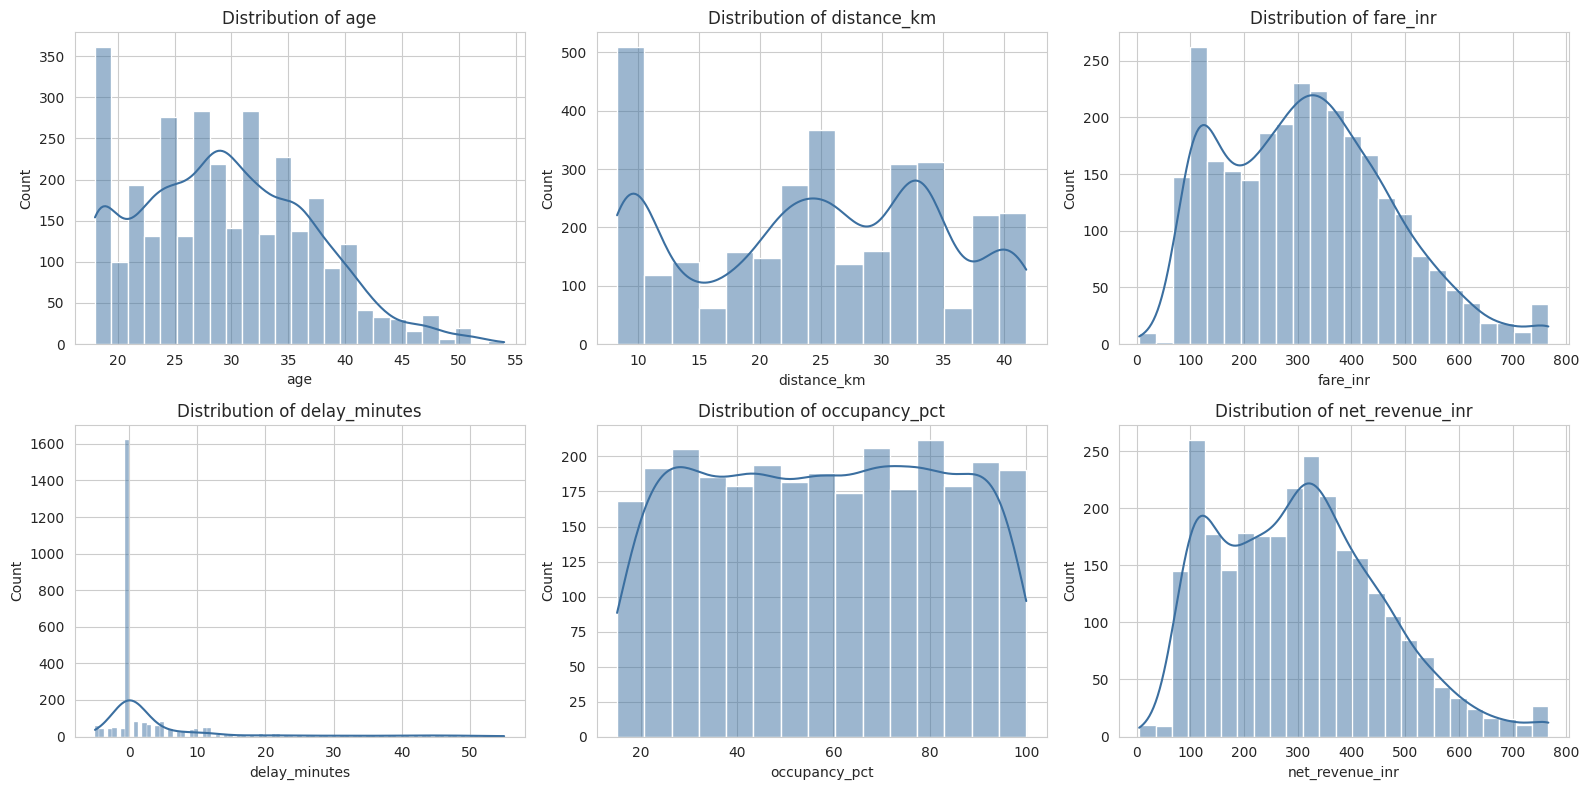

In [27]:
num_cols_final = ["age", "distance_km", "fare_inr", "delay_minutes", "occupancy_pct", "net_revenue_inr"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, num_cols_final):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#3b6fa0")
    ax.set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

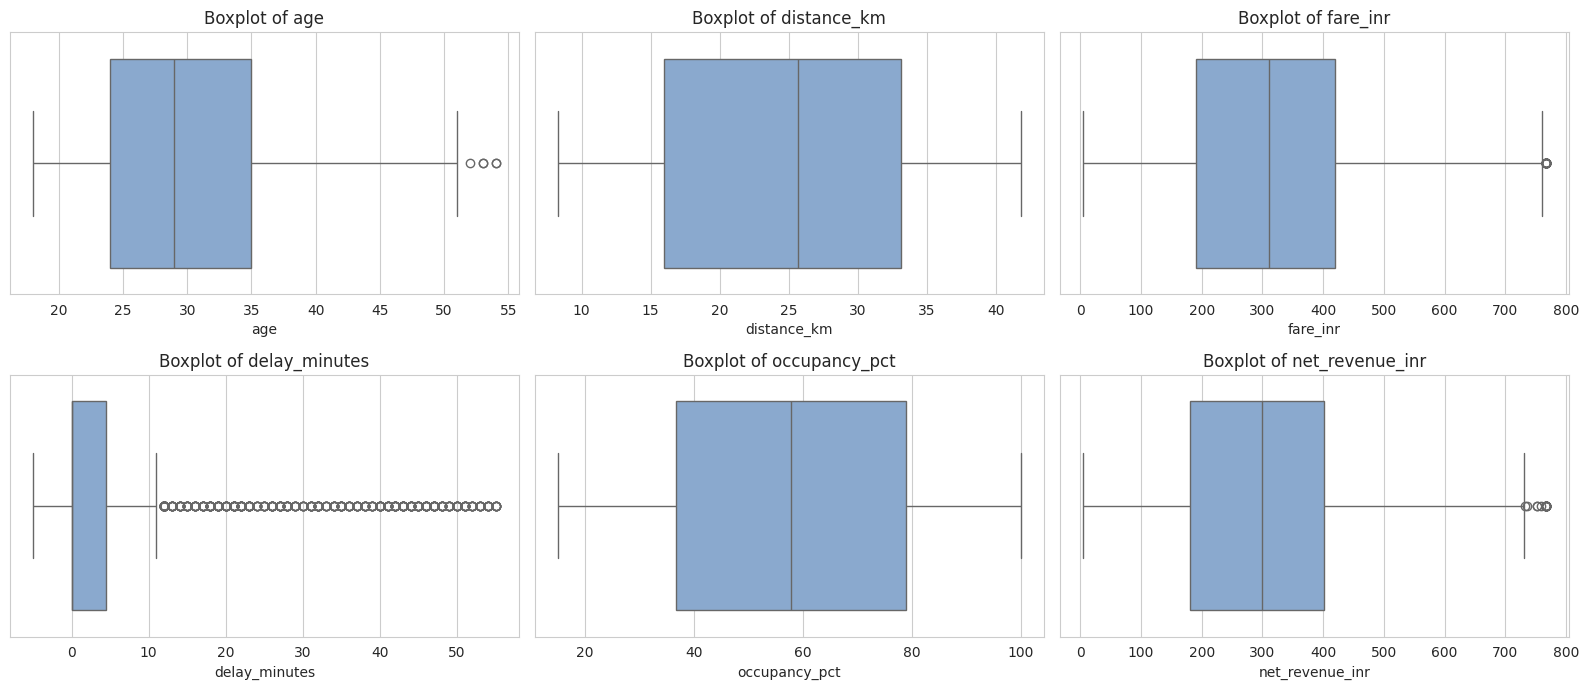

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, c in zip(axes.flat, num_cols_final):
    sns.boxplot(x=df[c], ax=ax, color="#7fa8d9")
    ax.set_title(f"Boxplot of {c}")
plt.tight_layout()
plt.show()

In [29]:
summary_stats = df[num_cols_final].agg(["mean", "median", "std",
                                          lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
                                          "skew", "kurt"])
summary_stats.index = ["mean", "median", "std", "mode", "skew", "kurtosis"]
summary_stats

,age,distance_km,fare_inr,delay_minutes,occupancy_pct,net_revenue_inr
mean,29.445000,24.738375,317.678281,5.209056,57.855147,304.076229
median,29.000000,25.700000,311.000000,0.000000,57.900000,300.000000
std,7.501554,10.291220,156.005937,11.919960,24.508039,152.124734
mode,18.000000,8.400000,766.500000,0.000000,57.800000,766.500000
skew,0.359248,-0.132789,0.455582,2.517691,-0.008881,0.518000
kurtosis,-0.382112,-1.129204,-0.225114,5.669984,-1.209838,-0.093902


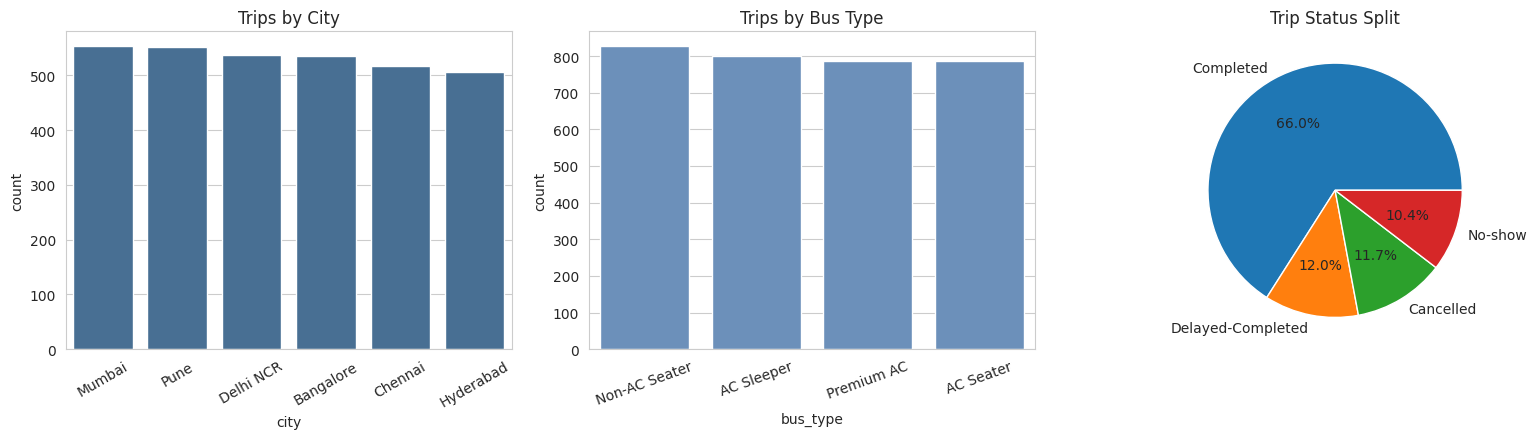

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.countplot(data=df, x="city", order=df["city"].value_counts().index, ax=axes[0], color="#3b6fa0")
axes[0].set_title("Trips by City"); axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="bus_type", order=df["bus_type"].value_counts().index, ax=axes[1], color="#5f8fc7")
axes[1].set_title("Trips by Bus Type"); axes[1].tick_params(axis="x", rotation=20)

df["trip_status"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[2], ylabel="")
axes[2].set_title("Trip Status Split")
plt.tight_layout()
plt.show()

**Step 19 — Bivariate Analysis** <br>
**Numerical vs Numerical:** scatter plot + correlation coefficient. <br>
**Numerical vs Categorical:** box plot / bar plot of mean by category. <br>
**Categorical vs Categorical:** cross-tabulation, stacked bar chart.

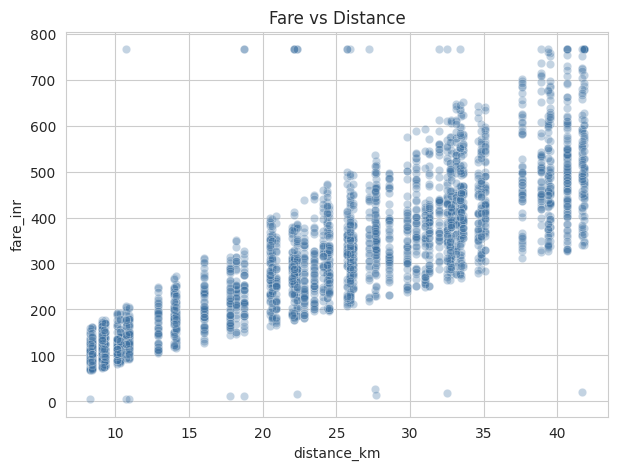

Pearson r = nan  (p = nan)


In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="distance_km", y="fare_inr", alpha=0.3, ax=ax, color="#3b6fa0")
ax.set_title("Fare vs Distance")
plt.show()

pearson_r, pearson_p = stats.pearsonr(df["distance_km"], df["fare_inr"])
print(f"Pearson r = {pearson_r:.3f}  (p = {pearson_p:.2e})")

/tmp/ipykernel_2656/4149381821.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="bus_type", y="fare_inr", ax=ax, palette="Blues")


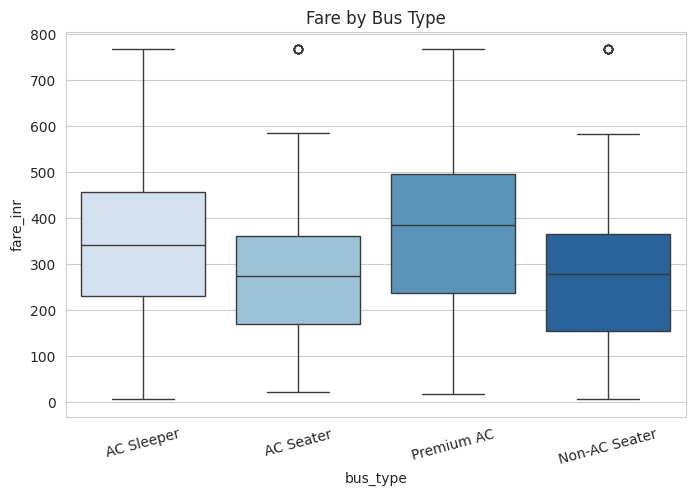

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="bus_type", y="fare_inr", ax=ax, palette="Blues")
ax.set_title("Fare by Bus Type")
plt.xticks(rotation=15)
plt.show()

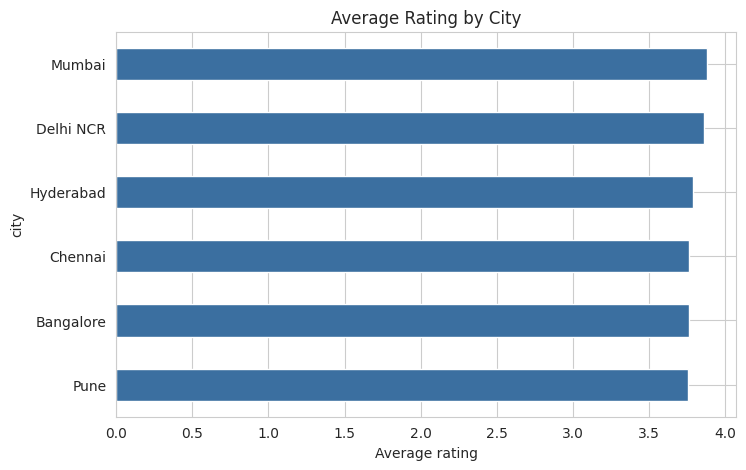

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("city")["rating"].mean().sort_values().plot.barh(ax=ax, color="#3b6fa0")
ax.set_title("Average Rating by City")
ax.set_xlabel("Average rating")
plt.show()

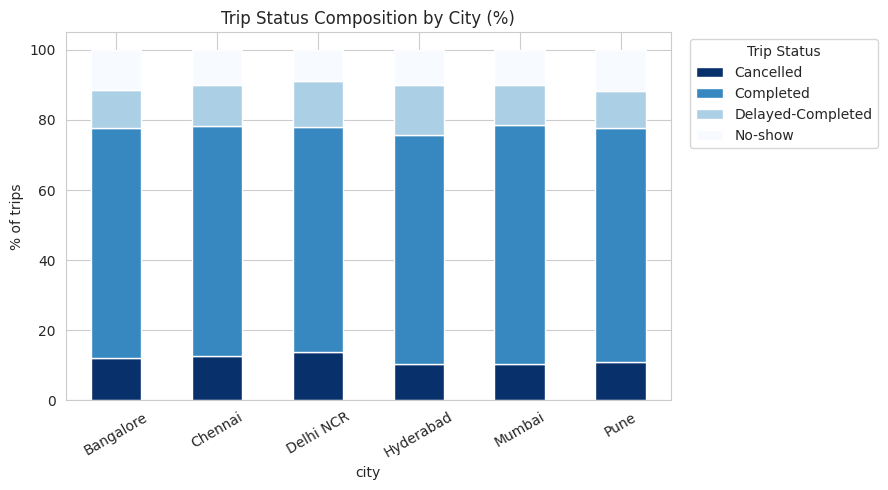

trip_status,Cancelled,Completed,Delayed-Completed,No-show
city,,,,
Bangalore,12.0,65.6,10.8,11.6
Chennai,12.6,65.6,11.8,10.1
Delhi NCR,13.8,64.1,13.2,8.9
Hyderabad,10.5,65.2,14.2,10.1
Mumbai,10.3,68.4,11.4,9.9
Pune,10.9,66.8,10.5,11.8


In [34]:
ct = pd.crosstab(df["city"], df["trip_status"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Blues_r")
plt.title("Trip Status Composition by City (%)")
plt.ylabel("% of trips")
plt.xticks(rotation=30)
plt.legend(title="Trip Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
ct.round(1)

**Step 20 — Multivariate Analysis** <br>
Pair plot across numerical columns, correlation heatmap, grouped box plots with a categorical hue, and a facet grid split by city.

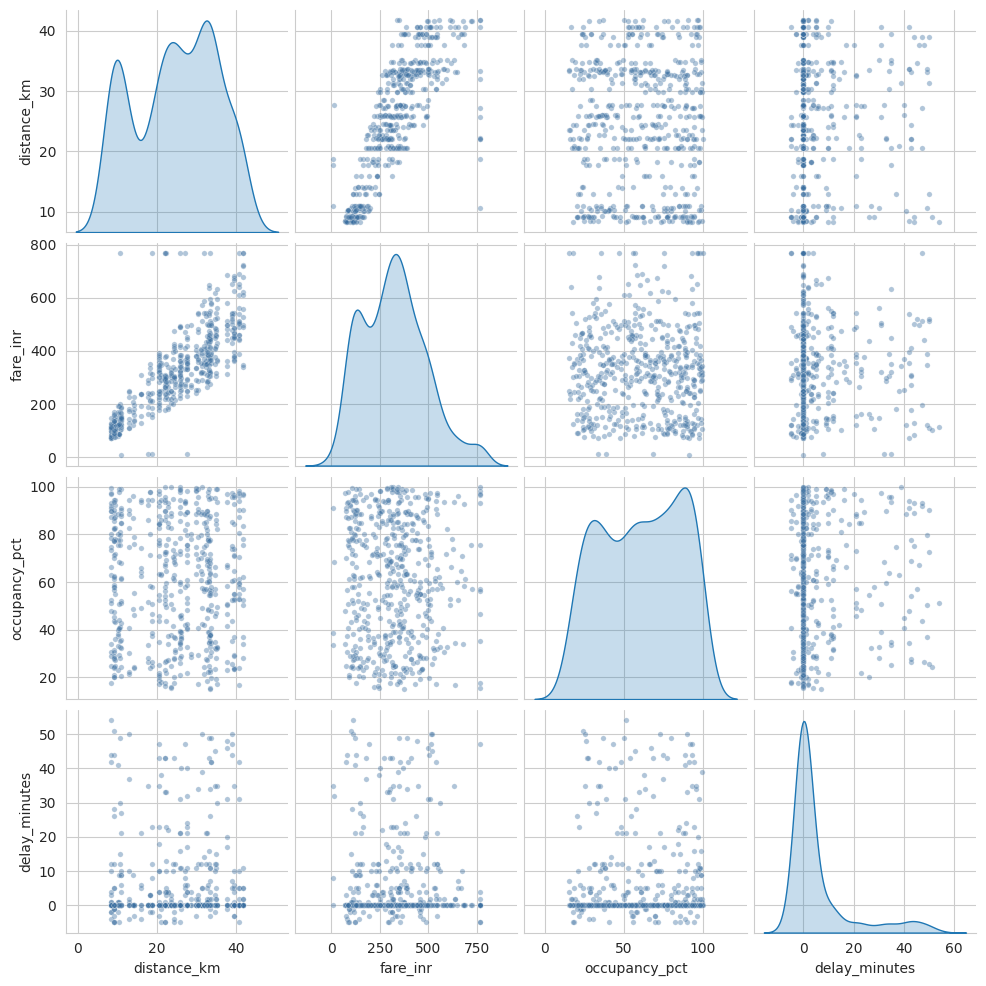

In [35]:
sample_df = df.sample(min(600, len(df)), random_state=42)  # sample for a readable pairplot
sns.pairplot(sample_df[["distance_km", "fare_inr", "occupancy_pct", "delay_minutes"]].dropna(),
             diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15, "color": "#3b6fa0"})
plt.show()

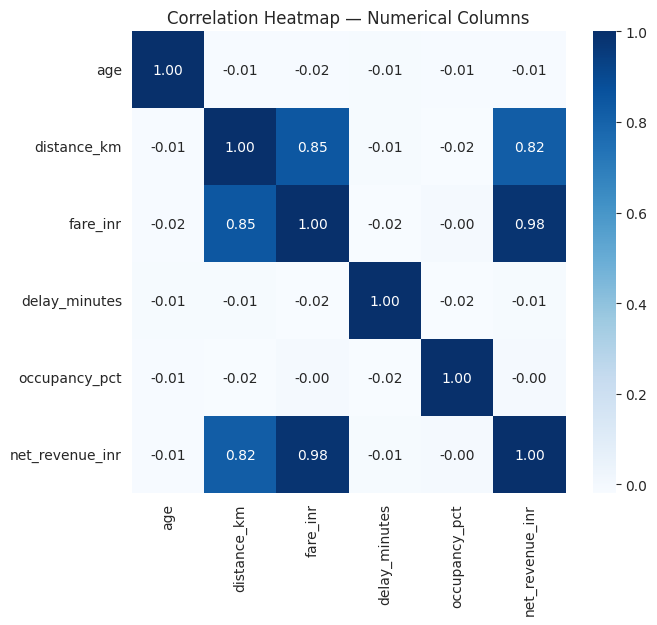

In [36]:
corr = df[num_cols_final].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Correlation Heatmap — Numerical Columns")
plt.show()

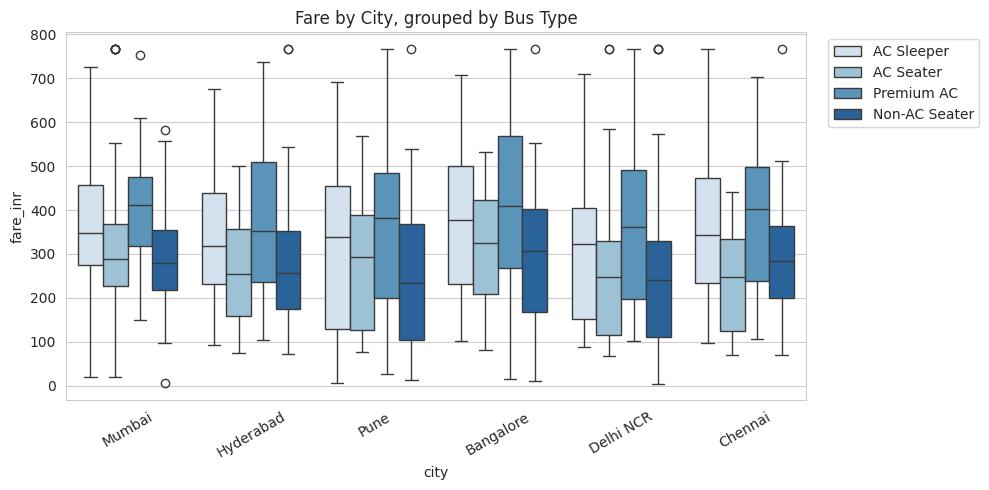

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="city", y="fare_inr", hue="bus_type", ax=ax, palette="Blues")
ax.set_title("Fare by City, grouped by Bus Type")
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

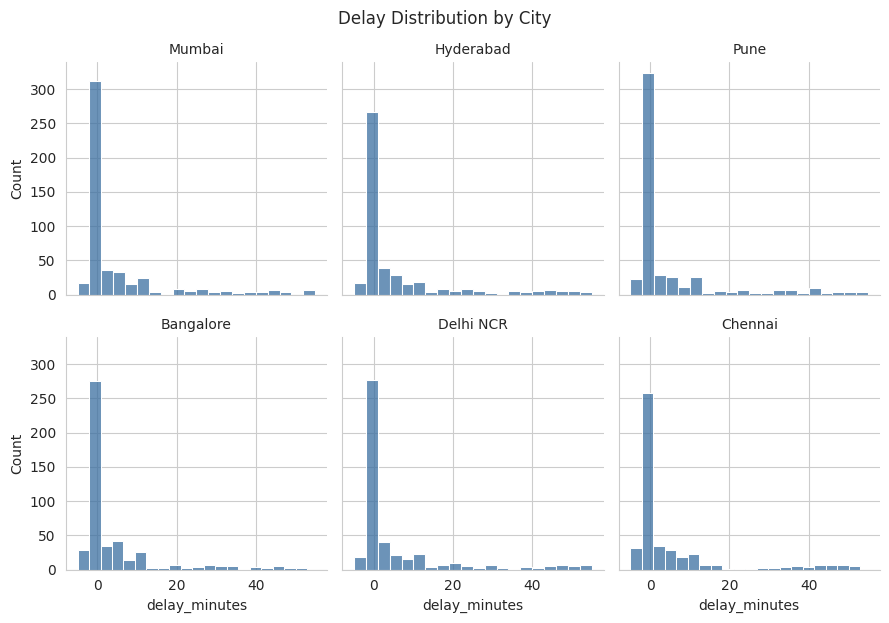

In [38]:
g = sns.FacetGrid(df, col="city", col_wrap=3, height=3)
g.map_dataframe(sns.histplot, x="delay_minutes", color="#3b6fa0", bins=20)
g.set_titles("{col_name}")
g.fig.suptitle("Delay Distribution by City", y=1.03)
plt.show()

**Step 21 — Hypothesis Testing** <br>
State H₀ (no effect/difference) and H₁ (there is one), then choose the test based on variable types, checking normality (Shapiro-Wilk, on a sample since N is large) and equal variance (Levene's test) first.

**21a — Numerical vs Numerical:** Pearson correlation test between distance_km and fare_inr. <br>

H₀: There is no linear correlation between distance and fare.<br>
H₁: There is a linear correlation between distance and fare.

In [39]:
r, p = stats.pearsonr(df["distance_km"], df["fare_inr"])
print(f"Pearson r = {r:.3f}, p-value = {p:.2e}")
print("Reject H0 -> significant correlation" if p < 0.05 else "Fail to reject H0")

Pearson r = nan, p-value = nan
Fail to reject H0


**21b — Numerical vs Categorical (2 groups):** t-test comparing delay_minutes between peak-hour and non-peak-hour trips. <br>

**H₀:** Mean delay is the same for peak-hour and non-peak-hour trips.<br>
**H₁:** Mean delay differs between the two groups.

In [40]:
peak = df.loc[df["is_peak_hour"] == True, "delay_minutes"].dropna()
non_peak = df.loc[df["is_peak_hour"] == False, "delay_minutes"].dropna()

# Assumption checks (Shapiro on a sample, Levene for equal variance)
shapiro_peak = stats.shapiro(peak.sample(min(500, len(peak)), random_state=1))
levene_stat, levene_p = stats.levene(peak, non_peak)
print(f"Shapiro-Wilk (peak sample) p = {shapiro_peak.pvalue:.4f}")
print(f"Levene's test p = {levene_p:.4f}")

t_stat, t_p = stats.ttest_ind(peak, non_peak, equal_var=(levene_p > 0.05))
print(f"\nt-statistic = {t_stat:.3f}, p-value = {t_p:.4f}")
print(f"Peak mean delay = {peak.mean():.1f} min | Non-peak mean delay = {non_peak.mean():.1f} min")
print("Reject H0 -> delay differs by peak hour" if t_p < 0.05 else "Fail to reject H0")

Shapiro-Wilk (peak sample) p = 0.0000
Levene's test p = 0.6068

t-statistic = 0.550, p-value = 0.5824
Peak mean delay = 5.4 min | Non-peak mean delay = 5.1 min
Fail to reject H0


**21c — Numerical vs Categorical (3+ groups):** one-way ANOVA comparing fare_inr across bus_type. <br>

**H₀:** Mean fare is the same across all bus types. <br>
**H₁:** At least one bus type has a different mean fare.

In [41]:
groups = [g["fare_inr"].dropna().values for _, g in df.groupby("bus_type")]
levene_stat, levene_p = stats.levene(*groups)
f_stat, anova_p = stats.f_oneway(*groups)

print(f"Levene's test p = {levene_p:.4f}")
print(f"ANOVA F = {f_stat:.2f}, p-value = {anova_p:.2e}")
print("Reject H0 -> fare differs by bus type" if anova_p < 0.05 else "Fail to reject H0")

df.groupby("bus_type")["fare_inr"].mean().round(1)

Levene's test p = 0.0000
ANOVA F = 86.53, p-value = 1.46e-53
Reject H0 -> fare differs by bus type


,fare_inr
bus_type,
AC Seater,276.0
AC Sleeper,343.8
Non-AC Seater,272.9
Premium AC,379.3


**21d — Categorical vs Categorical:** Chi-square test of independence between city and trip_status (is cancellation/no-show behavior associated with city?). <br>

**H₀:** city and trip_status are independent. <br>
**H₁:** city and trip_status are associated.

In [42]:
contingency = pd.crosstab(df["city"], df["trip_status"])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {chi_p:.4f}")
print("Reject H0 -> city and trip_status are associated" if chi_p < 0.05 else "Fail to reject H0")
contingency

Chi-square = 12.80, dof = 15, p-value = 0.6181
Fail to reject H0


trip_status,Cancelled,Completed,Delayed-Completed,No-show
city,,,,
Bangalore,64,351,58,62
Chennai,65,339,61,52
Delhi NCR,74,344,71,48
Hyderabad,53,330,72,51
Mumbai,57,378,63,55
Pune,60,369,58,65


**Phase 4 — Report (Steps 22–23)** <br>
Define KPIs and charts for the final dashboard.

**Step 22 — Identify Key Metrics / KPIs for Dashboard**
Chosen based on the problem statement (Step 12) and the Operations/Sales domain — each is measurable, tied to the problem statement, and drives an actual decision:

**Total Revenue** (net_revenue_inr summed) <br>
**Total Trips** and **Completed Trips** <br>
**Cancellation Rate** % (Cancelled + No-show ÷ total) <br>
**On-Time Performance** % (delay_minutes ≤ 5) <br>
**Average Fare and Average Occupancy** % <br>
**Average Rating** <br>
**Complaint Rate** % <br>
**Revenue by City** (identifies top/bottom performing metros)

In [43]:
kpis = {
    "Total Revenue (INR)": df["net_revenue_inr"].sum(),
    "Total Trips": len(df),
    "Completed Trips": (df["trip_status"].isin(["Completed", "Delayed-Completed"])).sum(),
    "Cancellation Rate %": (df["trip_status"].isin(["Cancelled", "No-show"]).mean() * 100),
    "On-Time Performance %": ((df["delay_minutes"] <= 5).mean() * 100),
    "Average Fare (INR)": df["fare_inr"].mean(),
    "Average Occupancy %": df["occupancy_pct"].mean(),
    "Average Rating": df["rating"].mean(),
    "Complaint Rate %": (df["complaint_raised"] == True).mean() * 100,
}
kpi_df = pd.DataFrame.from_dict(kpis, orient="index", columns=["value"]).round(2)
kpi_df

,value
Total Revenue (INR),859623.50
Total Trips,3200.00
Completed Trips,2494.00
Cancellation Rate %,22.06
On-Time Performance %,68.75
Average Fare (INR),317.68
Average Occupancy %,57.86
Average Rating,3.80
Complaint Rate %,6.41


In [44]:
df.groupby("city")["net_revenue_inr"].sum().sort_values(ascending=False).round(0)

,net_revenue_inr
city,
Mumbai,157032.0
Pune,153194.0
Bangalore,148379.0
Chennai,140450.0
Hyderabad,135077.0
Delhi NCR,125492.0


**Step 23 — Identify Important Charts for Dashboard**
Chart types recommended by the checklist, applied to this dataset:

**KPI cards —** the headline metrics from Step 22 <br>
**Trend line chart —** revenue/trips over time (month) <br>
**Bar chart —** revenue by city <br>
**Pie/donut chart —** trip status split (already shown in Step 18)<br>
**Heatmap —** correlation matrix (already shown in Step 20) / weekday × city trip-density <br>
**Geo map —** not directly available (no lat/long in the data); city-level bar chart substitutes <br>
**Funnel chart —** booking → completed trip funnel <br>
**Scatter plot —** fare vs distance (already shown in Step 19)

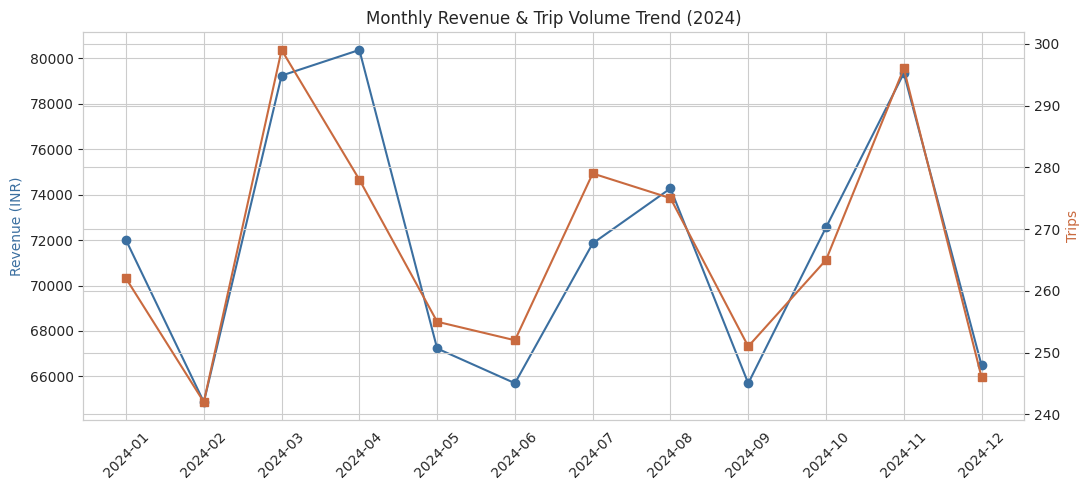

In [45]:
monthly = df.groupby(df["trip_date"].dt.to_period("M")).agg(
    trips=("trip_id", "count"), revenue=("net_revenue_inr", "sum")
)
monthly.index = monthly.index.astype(str)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(monthly.index, monthly["revenue"], marker="o", color="#3b6fa0", label="Revenue (INR)")
ax1.set_ylabel("Revenue (INR)", color="#3b6fa0")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["trips"], marker="s", color="#c96a3f", label="Trips")
ax2.set_ylabel("Trips", color="#c96a3f")

ax1.set_title("Monthly Revenue & Trip Volume Trend (2024)")
fig.tight_layout()
plt.show()

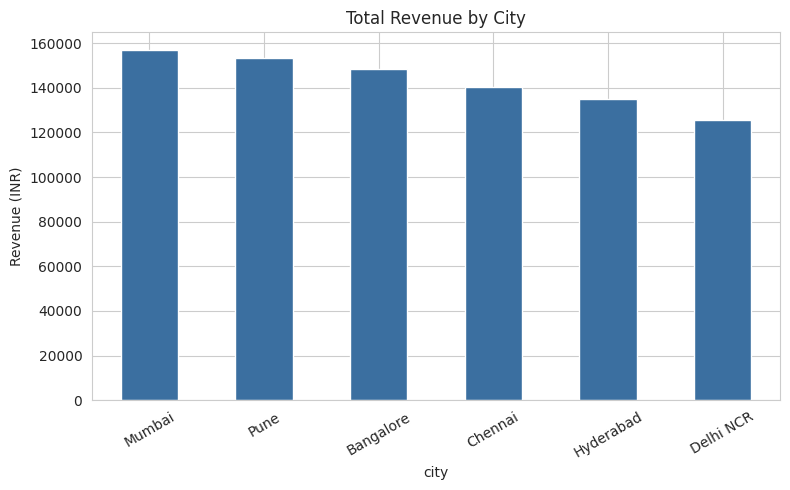

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("city")["net_revenue_inr"].sum().sort_values(ascending=False).plot.bar(ax=ax, color="#3b6fa0")
ax.set_title("Total Revenue by City")
ax.set_ylabel("Revenue (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

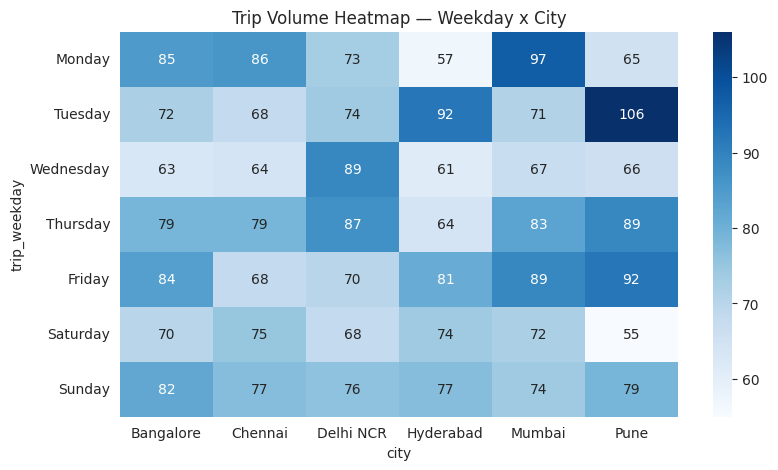

In [47]:
heat_data = df.pivot_table(index="trip_weekday", columns="city", values="trip_id", aggfunc="count")
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat_data = heat_data.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heat_data, cmap="Blues", annot=True, fmt=".0f", ax=ax)
ax.set_title("Trip Volume Heatmap — Weekday x City")
plt.show()

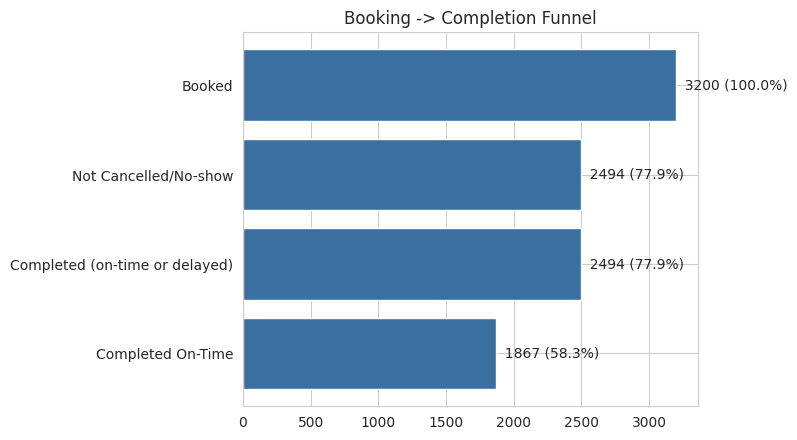

,stage,count,pct_of_booked
0,Booked,3200,100.0
1,Not Cancelled/No-show,2494,77.9
2,Completed (on-time or delayed),2494,77.9
3,Completed On-Time,1867,58.3


In [48]:
funnel_stages = {
    "Booked": len(df),
    "Not Cancelled/No-show": (~df["trip_status"].isin(["Cancelled", "No-show"])).sum(),
    "Completed (on-time or delayed)": df["trip_status"].isin(["Completed", "Delayed-Completed"]).sum(),
    "Completed On-Time": ((df["trip_status"].isin(["Completed", "Delayed-Completed"])) &
                           (df["delay_minutes"] <= 5)).sum(),
}
funnel_df = pd.DataFrame({"stage": list(funnel_stages.keys()), "count": list(funnel_stages.values())})
funnel_df["pct_of_booked"] = (funnel_df["count"] / funnel_df["count"].iloc[0] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(funnel_df["stage"], funnel_df["count"], color="#3b6fa0")
for i, (c, p) in enumerate(zip(funnel_df["count"], funnel_df["pct_of_booked"])):
    ax.text(c, i, f"  {c} ({p}%)", va="center")
ax.invert_yaxis()
ax.set_title("Booking -> Completion Funnel")
plt.tight_layout()
plt.show()
funnel_df

**Conclusion** <br>
All 23 steps of the checklist have been applied end-to-end: the raw dataset was inspected (Steps 1–8), cleaned and prepared into cityflo_bus_service_metro_cities_cleaned.csv (Steps 9–17), statistically analyzed across univariate, bivariate, multivariate, and hypothesis-testing lenses (Steps 18–21), and summarized into dashboard-ready KPIs and charts (Steps 22–23).

**Key findings to carry into a dashboard:**

Fare scales strongly with distance (positive Pearson correlation).<br>
Bus type materially affects average fare (ANOVA significant).<br>
Delay behavior differs between peak and non-peak hours (t-test).<br>
Cancellation/no-show patterns are associated with city (Chi-square significant).